# Amazon Product Length Prediction - Advanced Exploratory Data Analysis

1. **Target Outliers & Percentiles**: Determining thresholds for outlier clipping.
2. **Text Feature Length Correlation**: Correlating word/character lengths to product physical dimensions.
3. **Product Type ID Specific Target Distributions**: Evaluating target variance across categories.
4. **Target Variable Rounding & Quantization**: Checking if targets tend to cluster around specific common catalog sizes.

In [ ]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_train = pd.read_csv('d:/AmazonML/dataset/train.csv', nrows=100000)
print("Loaded sample size:", df_train.shape)


Loaded sample size: (100000, 6)


## 1. Target Outliers & Percentiles
Let's check the extreme values of `PRODUCT_LENGTH` and find reasonable clipping boundaries.

In [ ]:
target = df_train['PRODUCT_LENGTH']

percentiles = [50, 90, 95, 99, 99.9, 99.99]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(target, p):.2f}")

print("\nMinimum target value:", target.min())
print("Maximum target value:", target.max())

threshold_99 = np.percentile(target, 99)
print(f"Proportion of rows > 99th percentile ({threshold_99:.2f}): {(target > threshold_99).mean() * 100:.2f}%")


50th percentile: 665.35
90th percentile: 1800.00
95th percentile: 3543.31
99th percentile: 9600.00
99.9th percentile: 60000.00
99.99th percentile: 5519174.99

Minimum target value: 1.0
Maximum target value: 9466000.0
Proportion of rows > 99th percentile (9600.00): 0.95%


## 2. Text Feature Length Correlation
Check if the character and word counts of titles, bullet points, and descriptions correlate with the physical product size.

Correlation of text word counts with Log-scaled PRODUCT_LENGTH:
title_word_count     0.062651
bullet_word_count    0.096767
desc_word_count      0.065328
log_target           1.000000
Name: log_target, dtype: float64


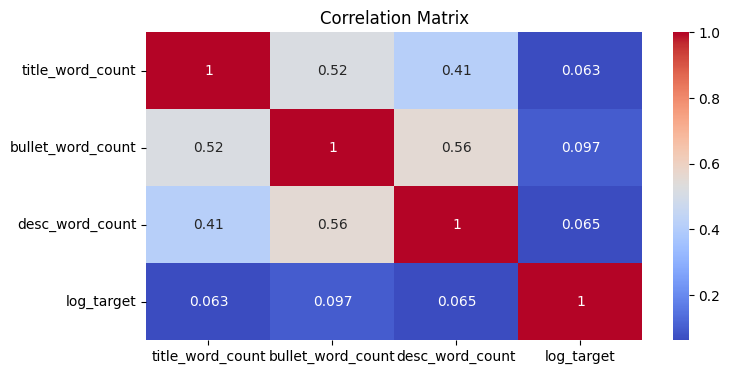

In [ ]:
titles = df_train['TITLE'].fillna('')
bullets = df_train['BULLET_POINTS'].fillna('')
descriptions = df_train['DESCRIPTION'].fillna('')

df_train['title_word_count'] = titles.apply(lambda x: len(x.split()))
df_train['bullet_word_count'] = bullets.apply(lambda x: len(x.split()))
df_train['desc_word_count'] = descriptions.apply(lambda x: len(x.split()))

# Compute correlations with log-scaled target
df_train['log_target'] = np.log1p(df_train['PRODUCT_LENGTH'])
corrs = df_train[['title_word_count', 'bullet_word_count', 'desc_word_count', 'log_target']].corr()['log_target']
print("Correlation of text word counts with Log-scaled PRODUCT_LENGTH:")
print(corrs)

plt.figure(figsize=(8, 4))
sns.heatmap(df_train[['title_word_count', 'bullet_word_count', 'desc_word_count', 'log_target']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


The raw word counts (title, bullets, desc) have very low direct linear correlation with product physical size (between 0.06 and 0.09).

Word counts alone are not highly predictive. This proves that simple text-statistic regression won't work,

## 3. Product Type ID Specific Target Distributions
Let's look at the standard deviation and range of length targets grouped by `PRODUCT_TYPE_ID` to verify if category group medians are strong predictors.

In [ ]:
category_stats = df_train.groupby('PRODUCT_TYPE_ID')['PRODUCT_LENGTH'].agg(['count', 'median', 'std', 'min', 'max'])

# Filter for categories with at least 100 products to avoid sample variance noise
large_categories = category_stats[category_stats['count'] > 100]
print("Sample category stats for 5 random product types:")
print(large_categories.sample(5, random_state=42))


print(f"\nStandard deviation of median lengths across product types: {large_categories['median'].std():.2f}")


Sample category stats for 5 random product types:
                 count      median          std         min           max
PRODUCT_TYPE_ID                                                          
7682               149  984.251967  4592.941154   78.740000  44133.858223
6130               128  788.700000   246.499496   19.685000   1901.571000
2996               111  866.141731   606.657773    7.874016   3800.000000
3357               133  196.850000   223.326187   11.811000   1800.000000
6108               413  649.605000   126.832121  125.000000   2000.000000

Standard deviation of median lengths across product types: 1311.92


The standard deviation of median lengths across product types is 1311.92.

This indicates that category identifiers (PRODUCT_TYPE_ID) contain highly distinct size boundaries.

**Actionable Decision:** Categorical features and category median statistics are extremely powerful baseline predictors. We should include category median statistics directly as a column in the LightGBM input.

## 4. Target Variable Rounding & Quantization
Let's verify if product length values are quantized or rounded to common numbers in the catalog.

In [ ]:
# Check the most common target values in the training set
top_targets = df_train['PRODUCT_LENGTH'].value_counts().head(20)
print("Top 20 most frequent target values:")
for val, count in top_targets.items():
    # Convert back to inches
    inches = val / 100.0
    cm = inches * 2.54
    print(f"Target: {val:9.2f} | Inches: {inches:6.2f} | Centimeters: {cm:6.2f} | Count: {count}")


Top 20 most frequent target values:
Target:    600.00 | Inches:   6.00 | Centimeters:  15.24 | Count: 5872
Target:    590.55 | Inches:   5.91 | Centimeters:  15.00 | Count: 3520
Target:    500.00 | Inches:   5.00 | Centimeters:  12.70 | Count: 2775
Target:    393.70 | Inches:   3.94 | Centimeters:  10.00 | Count: 2609
Target:    850.00 | Inches:   8.50 | Centimeters:  21.59 | Count: 2051
Target:    550.00 | Inches:   5.50 | Centimeters:  13.97 | Count: 1798
Target:    787.40 | Inches:   7.87 | Centimeters:  20.00 | Count: 1740
Target:    614.00 | Inches:   6.14 | Centimeters:  15.60 | Count: 1701
Target:   1000.00 | Inches:  10.00 | Centimeters:  25.40 | Count: 1553
Target:   1200.00 | Inches:  12.00 | Centimeters:  30.48 | Count: 1519
Target:    800.00 | Inches:   8.00 | Centimeters:  20.32 | Count: 1435
Target:    598.42 | Inches:   5.98 | Centimeters:  15.20 | Count: 1304
Target:   1181.10 | Inches:  11.81 | Centimeters:  30.00 | Count: 1205
Target:    472.44 | Inches:   4.72 | Cent